In [1]:
import numpy as np
import pandas as pd
import os

In [2]:
matches = pd.read_csv('/kaggle/input/t20matches/t20_matches.csv')
series = pd.read_csv('/kaggle/input/t20matches/t20_series.csv')
matches.shape,series.shape

((6417, 26), (373, 5))

In [3]:
matches.head(5)

,match_id,series_id,match_details,result,scores,date,venue,round,home,away,...,innings1_wickets,innings1_overs_batted,innings1_overs,innings2,innings2_runs,innings2_wickets,innings2_overs_batted,innings2_overs,D/L_method,target
0,304744,124121,North Group:Durham v Nottinghamshire at Cheste...,Durham won by 6 wickets (with 5 balls remaining),Nottinghamshire 157/7 (20/20 ov); Durham 160/4...,13/06/2003,Chester-le-Street,North Group,Durham,Nottinghamshire,...,7.0,20.0,20.0,Durham,160.0,4.0,19.1,20.0,NaN,NaN
1,129610,124121,South Group:Hampshire v Sussex at Southampton-...,Hampshire won by 5 runs,Hampshire 153 (19.4/20 ov); Sussex 148/7 (20/2...,13/06/2003,Southampton,South Group,Hampshire,Sussex,...,10.0,19.4,20.0,Sussex,148.0,7.0,20.0,20.0,NaN,NaN
2,129597,124121,Midlands/Wales/West Group:Somerset v Warwicksh...,Warwickshire won by 19 runs,Warwickshire 188/7 (20/20 ov); Somerset 169 (2...,13/06/2003,Taunton,Midlands/Wales/West Group,Somerset,Warwickshire,...,7.0,20.0,20.0,Somerset,169.0,10.0,20.0,20.0,NaN,NaN
3,304745,124121,South Group:Surrey v Middlesex at The Oval- Ju...,Surrey won by 4 wickets (with 4 balls remaining),Middlesex 155 (20/20 ov); Surrey 158/6 (19.2/2...,13/06/2003,The Oval,South Group,Surrey,Middlesex,...,10.0,20.0,20.0,Surrey,158.0,6.0,19.2,20.0,NaN,NaN
4,304746,124121,Midlands/Wales/West Group:Worcestershire v Nor...,Worcestershire won by 1 wicket (with 2 balls r...,Northamptonshire 150/9 (20/20 ov); Worcestersh...,13/06/2003,Worcester,Midlands/Wales/West Group,Worcestershire,Northamptonshire,...,9.0,20.0,20.0,Worcestershire,151.0,9.0,19.4,20.0,NaN,NaN


In [4]:
matches.home.nunique()

321

In [5]:
matches.away.nunique()

315

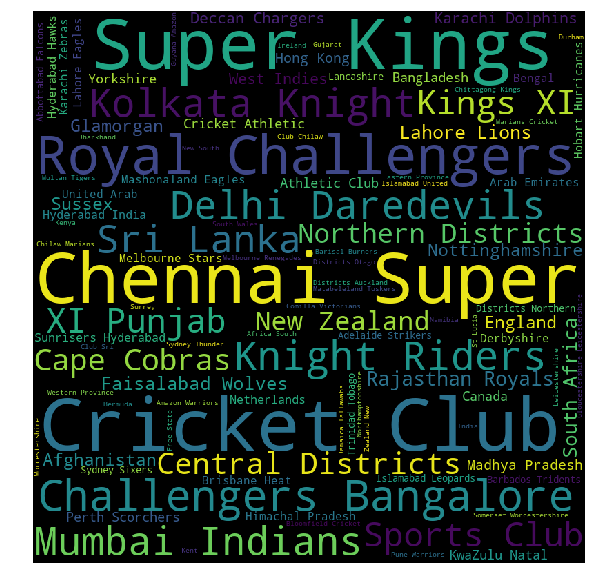

In [6]:
import matplotlib.pyplot as plt 
import seaborn as sns

names = ' '
for name in matches.home:
    name = str(name)
    names = names + name + ' '
from wordcloud import WordCloud, STOPWORDS 
wordcloud = WordCloud(width = 800, height = 800, 
                background_color ='black',  
                min_font_size = 10).generate(names) 
  
# plot the WordCloud image                        
plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() 

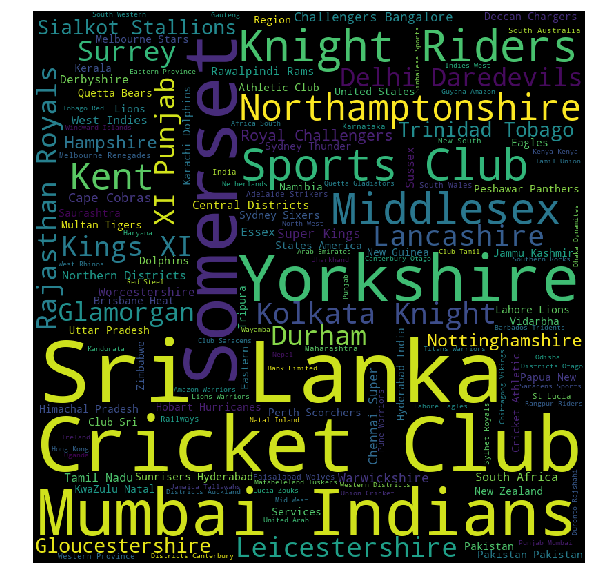

In [7]:
names = ' '
for name in matches.away:
    name = str(name)
    names = names + name + ' '
from wordcloud import WordCloud, STOPWORDS 
wordcloud = WordCloud(width = 800, height = 800, 
                background_color ='black',  
                min_font_size = 10).generate(names) 
  
# plot the WordCloud image                        
plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() 

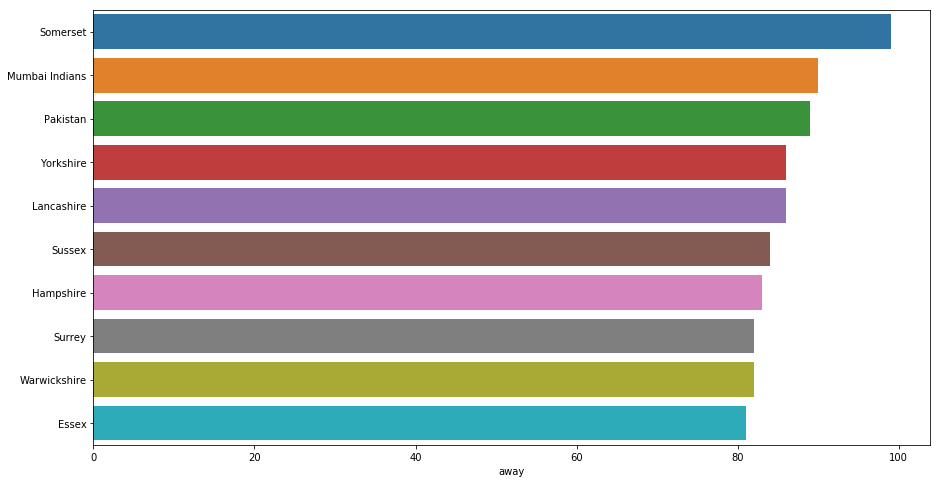

In [8]:
values = matches.away.value_counts().sort_values(ascending=False).head(10)
labels = values.index
plt.figure(figsize=(15,8))
sns.barplot(x=values, y=labels)

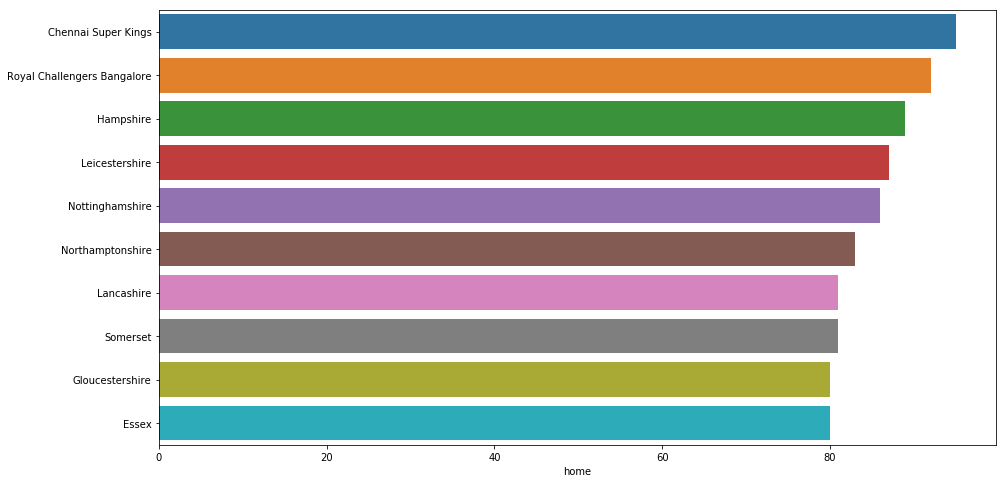

In [9]:
values = matches.home.value_counts().sort_values(ascending=False).head(10)
labels = values.index
plt.figure(figsize=(15,8))
sns.barplot(x=values, y=labels)

In [10]:
matches.columns

Index(['match_id', 'series_id', 'match_details', 'result', 'scores', 'date',
       'venue', 'round', 'home', 'away', 'winner', 'win_by_runs',
       'win_by_wickets', 'balls_remaining', 'innings1', 'innings1_runs',
       'innings1_wickets', 'innings1_overs_batted', 'innings1_overs',
       'innings2', 'innings2_runs', 'innings2_wickets',
       'innings2_overs_batted', 'innings2_overs', 'D/L_method', 'target'],
      dtype='object')

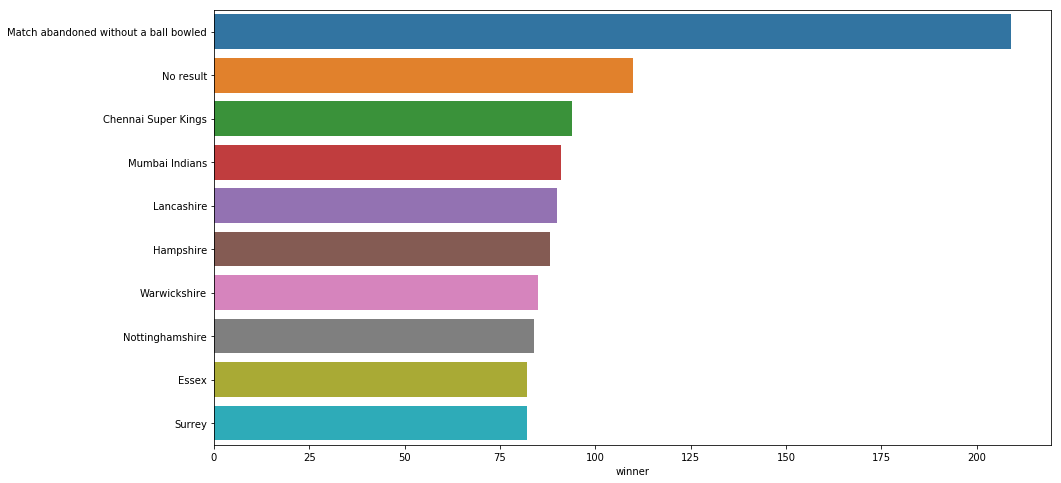

In [11]:
values = matches.winner.value_counts().sort_values(ascending=False).head(10)
labels = values.index
plt.figure(figsize=(15,8))
sns.barplot(x=values, y=labels)

In [12]:
matches['innings1_runs'].max(),matches['innings1_runs'].min()

(263.0, 1.0)

In [13]:
#Match with maximum score of 263 runs
matches.loc[matches['innings1_runs'].idxmax()]

match_id                                                            598027
series_id                                                           586733
match_details            31st match:Royal Challengers Bangalore v Pune ...
result                         Royal Challengers Bangalore won by 130 runs
scores                   Royal Challengers Bangalore 263/5 (20/20 ov); ...
date                                                            23/04/2013
venue                                                            Bangalore
round                                                           31st match
home                                           Royal Challengers Bangalore
away                                                         Pune Warriors
winner                                         Royal Challengers Bangalore
win_by_runs                                                            130
win_by_wickets                                                         NaN
balls_remaining          

In [14]:
#Match with minimum score of 1 run
matches.loc[matches['innings1_runs'].idxmin()]

match_id                                                            631943
series_id                                                           631939
match_details            1st unofficial T20I:West Indies A v Sri Lanka ...
result                                                           No result
scores                                         Sri Lanka A 1/0 (0.3/20 ov)
date                                                            18/06/2013
venue                                                            Kingstown
round                                                  1st unofficial T20I
home                                                         West Indies A
away                                                           Sri Lanka A
winner                                                           No result
win_by_runs                                                            NaN
win_by_wickets                                                         NaN
balls_remaining          

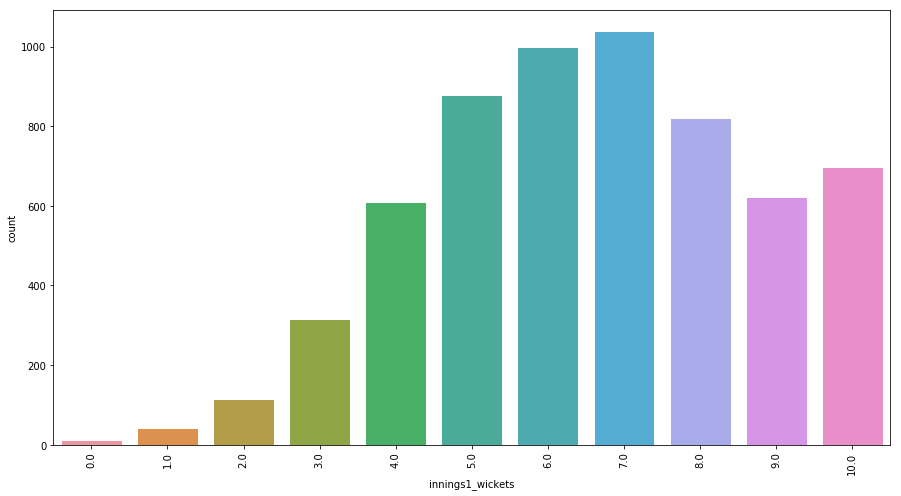

In [15]:
plt.figure(figsize=(15,8))
plt.xticks(rotation=90)
sns.set()
sns.set(style="darkgrid")
ax = sns.countplot(x=matches['innings1_wickets'], data=matches)

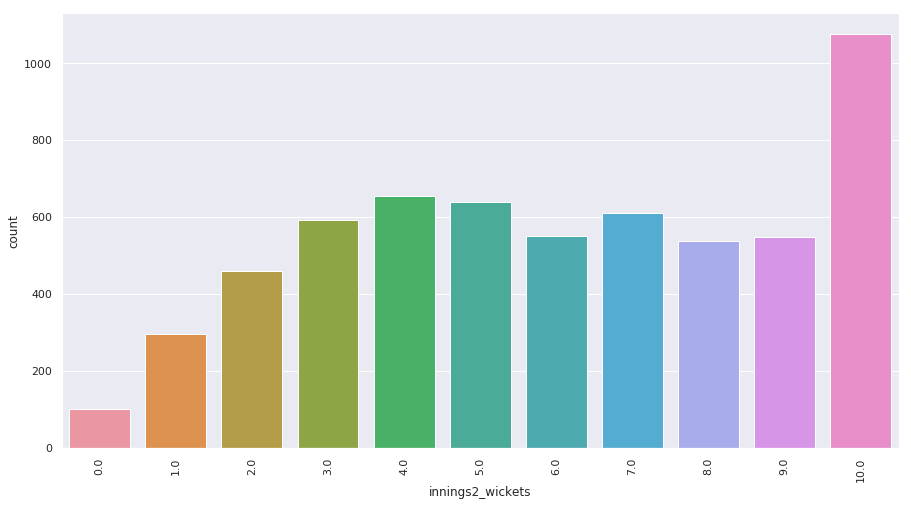

In [16]:
plt.figure(figsize=(15,8))
plt.xticks(rotation=90)
sns.set()
sns.set(style="darkgrid")
ax = sns.countplot(x=matches['innings2_wickets'], data=matches)

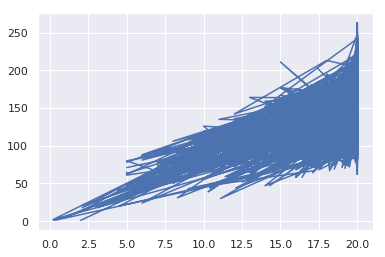

In [17]:
plt.plot(matches['innings1_overs_batted'],matches['innings1_runs'])

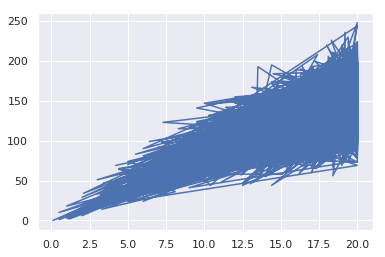

In [18]:
plt.plot(matches['innings2_overs_batted'],matches['innings2_runs'])

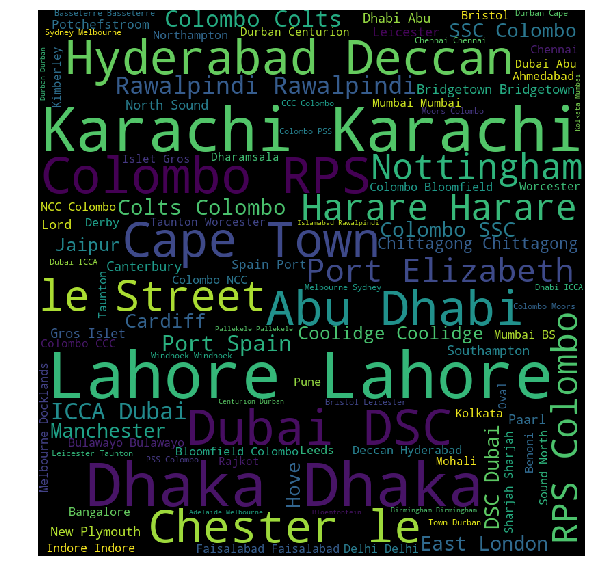

In [19]:
names = ' '
for name in matches.venue:
    name = str(name)
    names = names + name + ' '
from wordcloud import WordCloud, STOPWORDS 
wordcloud = WordCloud(width = 800, height = 800, 
                background_color ='black',  
                min_font_size = 10).generate(names) 
  
# plot the WordCloud image                        
plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud) 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() 

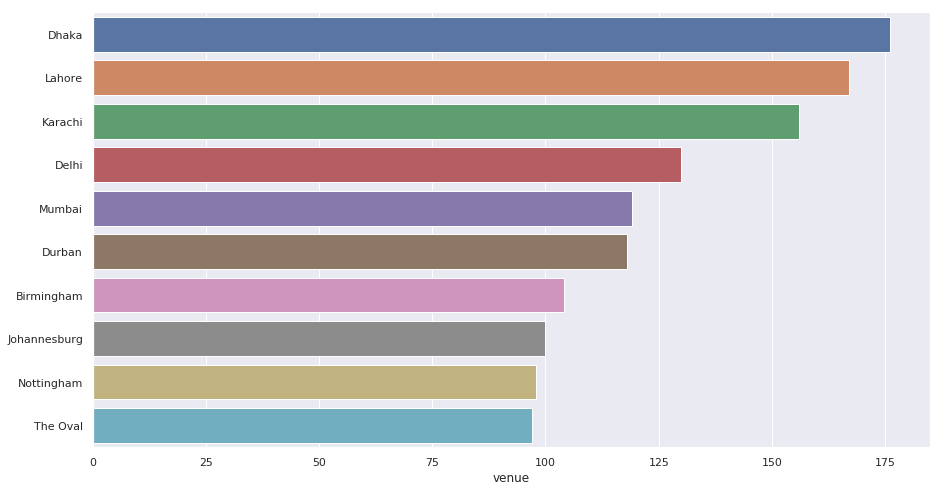

In [20]:
#Top 10 Grounds
values = matches.venue.value_counts().sort_values(ascending=False).head(10)
labels = values.index
plt.figure(figsize=(15,8))
sns.barplot(x=values, y=labels)

In [21]:
#Match with max no of runs margin for victory
matches.loc[matches['win_by_runs'].idxmax()]

match_id                                                            287860
series_id                                                           286109
match_details            8th Match, Group C:Kenya v Sri Lanka at Johann...
result                                           Sri Lanka won by 172 runs
scores                   Sri Lanka 260/6 (20/20 ov); Kenya 88 (19.3/20 ov)
date                                                            14/09/2007
venue                                                         Johannesburg
round                                                   8th Match, Group C
home                                                                 Kenya
away                                                             Sri Lanka
winner                                                           Sri Lanka
win_by_runs                                                            172
win_by_wickets                                                         NaN
balls_remaining          

In [22]:
#Match with min no of runs margin for victory
matches.loc[matches['win_by_runs'].idxmin()]

match_id                                                            304778
series_id                                                           124121
match_details            North Group:Leicestershire v Derbyshire at Lei...
result                                         Leicestershire won by 1 run
scores                   Leicestershire 171/8 (20/20 ov); Derbyshire 17...
date                                                            24/06/2003
venue                                                            Leicester
round                                                          North Group
home                                                        Leicestershire
away                                                            Derbyshire
winner                                                      Leicestershire
win_by_runs                                                              1
win_by_wickets                                                         NaN
balls_remaining          

In [23]:
series.head()

,series,season,winner,margin,series_id
0,Twenty20 Cup,2003,Surrey,NaN,124121
1,Standard Bank Pro20 Series (in South Africa),2003/04,Eagles,NaN,134226
2,Twenty20 Cup (in England),2004,Leics,NaN,134471
3,Twenty-20 Tournament (in Sri Lanka),2004,Chilaw,NaN,304926
4,Australia in New Zealand T20I Match,2004/05,Australia,1-0 (1),238218


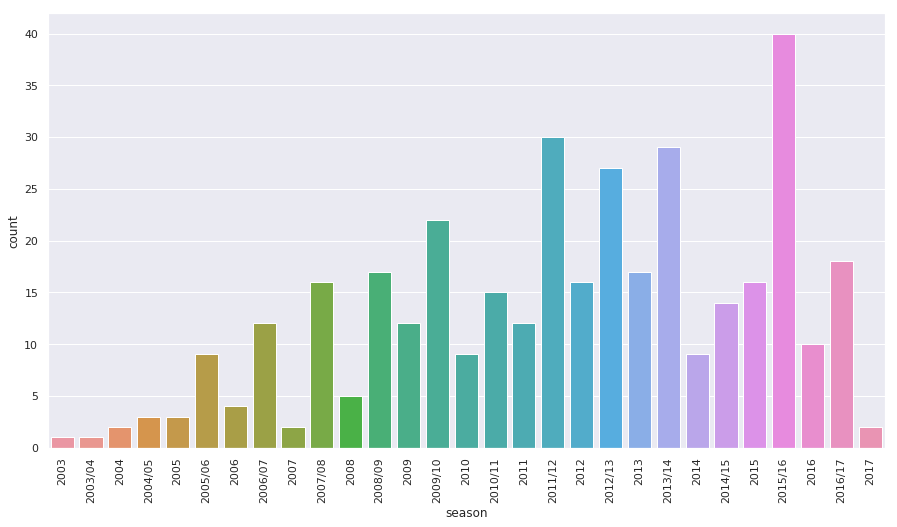

In [24]:
plt.figure(figsize=(15,8))
plt.xticks(rotation=90)
sns.set()
sns.set(style="darkgrid")
ax = sns.countplot(x=series['season'], data=series)

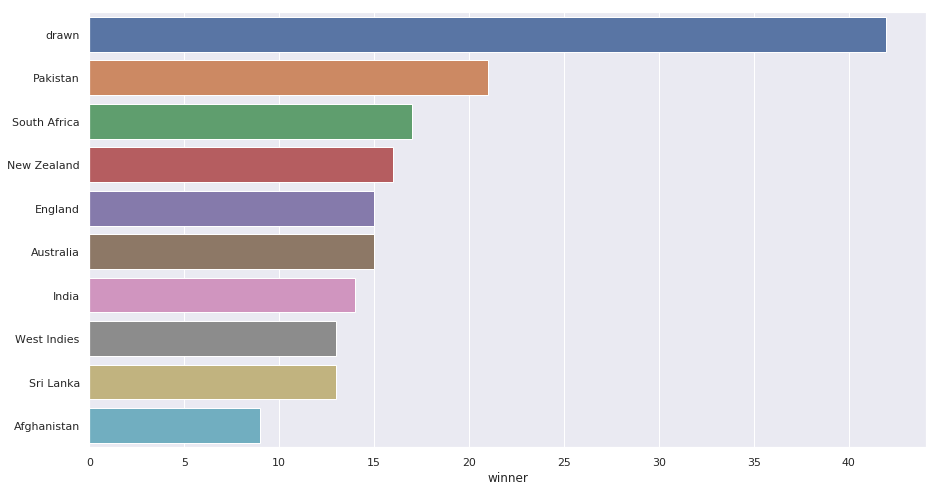

In [25]:
#Top 10 Series Winners
values = series.winner.value_counts().sort_values(ascending=False).head(10)
labels = values.index
plt.figure(figsize=(15,8))
sns.barplot(x=values, y=labels)

In [26]:
series['series'] = series.series.str.split('(',expand=True)

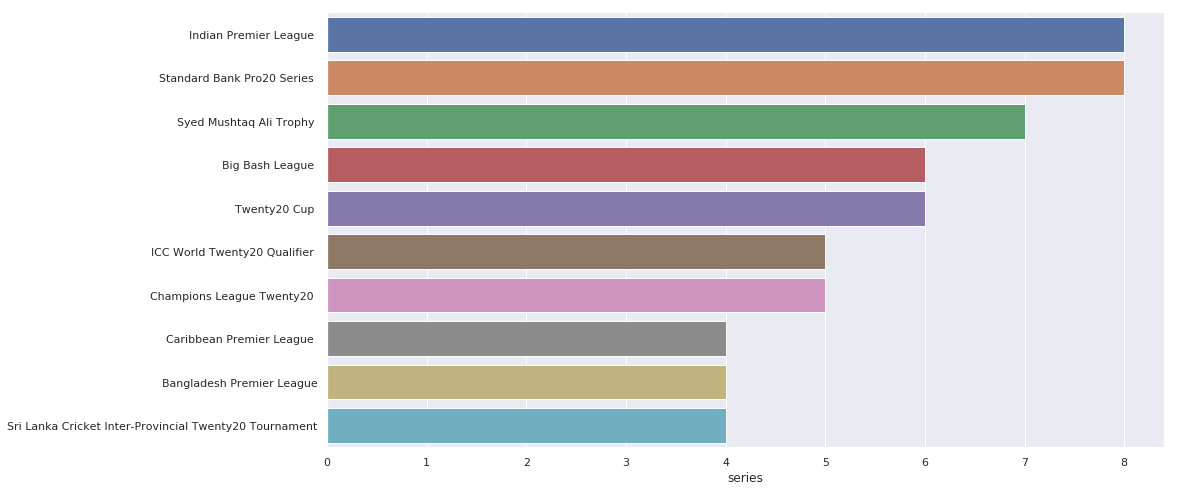

In [27]:
#Top 10 Series 
values = series.series.value_counts().sort_values(ascending=False).head(10)
labels = values.index
plt.figure(figsize=(15,8))
sns.barplot(x=values, y=labels)

In [28]:
x = series.margin.str.split('(',expand=True)[1]
x = x.str.split(')',expand=True)[0]

In [29]:
series['Margin'] = x

In [30]:
series.drop(['margin'],axis=1,inplace=True)

In [31]:
series.head()

,series,season,winner,series_id,Margin
0,Twenty20 Cup,2003,Surrey,124121,NaN
1,Standard Bank Pro20 Series,2003/04,Eagles,134226,NaN
2,Twenty20 Cup,2004,Leics,134471,NaN
3,Twenty-20 Tournament,2004,Chilaw,304926,NaN
4,Australia in New Zealand T20I Match,2004/05,Australia,238218,1


In [32]:
#Series Win by max margin
series.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 373 entries, 0 to 372
Data columns (total 5 columns):
series       373 non-null object
season       373 non-null object
winner       373 non-null object
series_id    373 non-null int64
Margin       201 non-null object
dtypes: int64(1), object(4)
memory usage: 14.7+ KB


In [33]:
series = series.astype({"Margin": float})

In [34]:
series.loc[series['Margin'].idxmax()]

series       Kenya in Namibia unofficial T20I Series
season                                       2011/12
winner                                       Namibia
series_id                                     538150
Margin                                             8
Name: 152, dtype: object

In [35]:
#All the series where winning Margin was more than or equal to 4 
series.loc[series['Margin']>=4]

,series,season,winner,series_id,Margin
146,Scotland in Namibia unofficial T20I Series,2011/12,Scotland,529473,5.0
152,Kenya in Namibia unofficial T20I Series,2011/12,Namibia,538150,8.0
239,Kenya in Sri Lanka unofficial T20I Series,2013/14,Sri Lanka A,682197,7.0
278,Hong Kong v Nepal T20I Series,2014/15,Hong Kong,800057,5.0
291,Scotland in Ireland T20I Series,2015,Scotland,876459,4.0
293,Nepal in Netherlands T20I Series,2015,Netherlands,883339,4.0
318,Pakistan A v England Lions unofficial T20I Ser...,2015/16,Eng Lions,921197,5.0
323,Walton T20 Cricket Series,2015/16,drawn,958413,4.0
370,Pakistan in West Indies T20I Series,2017,Pakistan,1077945,4.0


**Model will be made for winner prediction in next update**